In [2]:
pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 1.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 9.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
# ============================================================
# Cell 1 — Install (same stack as bench.ipynb, no torch conflicts)
# Use a FRESH Kaggle GPU session. Internet ON.
# ============================================================
import subprocess, sys

def pipi(*args):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *args]
    print(">>", " ".join(cmd))
    subprocess.check_call(cmd)

pipi("-U", "pip", "wheel")
pipi("shapely", "tqdm", "pillow", "opencv-python-headless", "PyYAML", "lmdb", "pyclipper")

# PaddlePaddle GPU (cu118 wheel — same as bench.ipynb)
try:
    pipi(
        "paddlepaddle-gpu==3.0.0",
        "-i", "https://www.paddlepaddle.org.cn/packages/stable/cu118/",
    )
except subprocess.CalledProcessError:
    print("GPU wheel failed — falling back to CPU paddle (slow but functional)")
    pipi("paddlepaddle")

# langchain stubs needed by paddleocr/paddlex on Kaggle
pipi("langchain-core", "langchain-text-splitters")
pipi("paddleocr")

print("\n Install complete. If 'PDX has already been initialized' appears later, "
      "restart the session and Run All from THIS cell.")

>> /usr/bin/python3 -m pip install -q -U pip wheel
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 36.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.


>> /usr/bin/python3 -m pip install -q shapely tqdm pillow opencv-python-headless PyYAML lmdb pyclipper
>> /usr/bin/python3 -m pip install -q paddlepaddle-gpu==3.0.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.


>> /usr/bin/python3 -m pip install -q langchain-core langchain-text-splitters
>> /usr/bin/python3 -m pip install -q paddleocr


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires PyYAML<6.1,>=6.0.3, but you have pyyaml 6.0.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0


 Install complete. If 'PDX has already been initialized' appears later, restart the session and Run All from THIS cell.


In [5]:
# ============================================================
# Cell 2 — Clone PaddleOCR repo (needed for training configs)
# ============================================================
import os, subprocess

REPO_DIR = "/kaggle/working/PaddleOCR"
if not os.path.isdir(REPO_DIR):
    subprocess.check_call(["git", "clone", "--depth", "1",
                           "https://github.com/PaddlePaddle/PaddleOCR.git",
                           REPO_DIR])
    print(" PaddleOCR repo cloned")
else:
    print(" Repo already present")

# Add repo root to path so `tools/train.py` can import ppocr modules
import sys
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
print("REPO_DIR:", REPO_DIR)

Cloning into '/kaggle/working/PaddleOCR'...


 PaddleOCR repo cloned
REPO_DIR: /kaggle/working/PaddleOCR


In [7]:
# ============================================================
# Imports & constants  (from both notebooks)
# ============================================================
import os, glob, re, random, subprocess, sys
import cv2
import numpy as np
import torch
import paddle
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

SEED        = 42
INPUT_SIZE  = 640
REC_H, REC_W = 48, 320
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

BASE      = "/kaggle/input/datasets/hungkhoi/vietnamese-scene-text-spotting-dataset-vintext/vintext/vintext"
TRAIN_DIR = os.path.join(BASE, "train_images")
LABEL_DIR = os.path.join(BASE, "labels")
OUT_DIR   = "/kaggle/working/ppocrv3_rec_vintext"
REPO_DIR  = "/kaggle/working/PaddleOCR"
os.makedirs(OUT_DIR, exist_ok=True)

PADDLE_DEVICE = "gpu" if (paddle.device.is_compiled_with_cuda()
                          and paddle.device.cuda.device_count() > 0) else "cpu"

random.seed(SEED)
np.random.seed(SEED)

In [8]:
# ============================================================
# Dataset helpers
# ============================================================
def parse_annotation(gt_path):
    records = []
    if not os.path.exists(gt_path): return records
    with open(gt_path, encoding="utf-8", errors="replace") as f:
        for line in f:
            parts = line.strip().split(",", 8)
            if len(parts) < 9: continue
            try: coords = list(map(float, parts[:8]))
            except ValueError: continue
            records.append(np.array(coords, dtype=np.float32).reshape(4, 2))
    return records

def _img_idx(name):
    m = re.search(r"(\d+)", os.path.basename(name))
    return int(m.group(1)) if m else None

sample_path = sorted(
    glob.glob(os.path.join(TRAIN_DIR, "*.jpg")) +
    glob.glob(os.path.join(TRAIN_DIR, "*.png"))
)[0]
img_bgr = cv2.imread(sample_path)
polys   = parse_annotation(os.path.join(LABEL_DIR, f"gt_{_img_idx(sample_path)}.txt"))
print(f"Image: {os.path.basename(sample_path)}  {img_bgr.shape}  {len(polys)} GT regions")

Image: im0001.jpg  (288, 512, 3)  30 GT regions


In [9]:
# ============================================================
# Load frozen PP-OCRv3 detector  (Cell 5 of ppocrv3-recog-20fixed.ipynb)
# .pth → paddle weights → PaddleOCR inference graph → TextDetector
# ============================================================

# 1. Find the pretrained .pth
DET_PTH_CANDIDATES = [
    "/kaggle/working/ppocrv3_det_vintext/ppocrv3_mobile_det_vintext.pth",
    "/kaggle/input/models/doddkaggleancut/detect/pytorch/default/1/ppocrv3_mobile_det_vintext.pth",
    "/kaggle/input/ppocrv3-mobile-det-vintext/ppocrv3_mobile_det_vintext.pth",
    "/kaggle/input/ppocrv3-det-vintext/ppocrv3_mobile_det_vintext.pth",
]
def _find_det_pth():
    for p in DET_PTH_CANDIDATES:
        if os.path.isfile(p): return p
    for base in glob.glob("/kaggle/input/*"):
        for root, _, files in os.walk(base):
            if "ppocrv3_mobile_det_vintext.pth" in files:
                return os.path.join(root, "ppocrv3_mobile_det_vintext.pth")
    return None

DET_PTH = _find_det_pth()
assert DET_PTH, "ppocrv3_mobile_det_vintext.pth not found. Add it as a Kaggle dataset input."
print(f"Detector .pth: {DET_PTH}")

# 2. Convert .pth → .pdparams  (same as Cell 5)
DET_INFER_DIR = os.path.join(OUT_DIR, "det_inference")
DET_CONFIG_PATH = os.path.join(OUT_DIR, "ppocrv3_det_export.yml")
CKPT_STEM = os.path.join(OUT_DIR, "det_ckpt")
os.makedirs(DET_INFER_DIR, exist_ok=True)

try:  ts = torch.load(DET_PTH, map_location="cpu", weights_only=False)
except TypeError: ts = torch.load(DET_PTH, map_location="cpu")
if isinstance(ts, dict) and "state_dict" in ts: ts = ts["state_dict"]
paddle_state = {
    k: paddle.to_tensor(v.detach().cpu().numpy() if hasattr(v, "detach") else np.asarray(v))
    for k, v in ts.items()
}
paddle.save(paddle_state, CKPT_STEM + ".pdparams")
print(f"Saved {CKPT_STEM}.pdparams ({len(paddle_state)} tensors)")

# 3. Write export config  (same as Cell 5)
DET_EXPORT_LABEL = os.path.join(OUT_DIR, "det_export_dummy.txt")
open(DET_EXPORT_LABEL, "w").close()
det_export_yaml = f"""Global:
  use_gpu: {'true' if PADDLE_DEVICE == 'gpu' else 'false'}
  epoch_num: 1
  save_model_dir: {OUT_DIR}
  pretrained_model:
  checkpoints:
  save_inference_dir:
  character_type: ch
  max_text_length: 25
  infer_mode: false
  use_space_char: true
Architecture:
  model_type: det
  algorithm: DB
  Transform:
  Backbone:
    name: MobileNetV3
    scale: 0.5
    model_name: large
    disable_se: true
  Neck:
    name: RSEFPN
    out_channels: 96
    shortcut: true
  Head:
    name: DBHead
    k: 50
Loss:
  name: DBLoss
  balance_loss: true
  main_loss_type: DiceLoss
  alpha: 5
  beta: 10
  ohem_ratio: 3
PostProcess:
  name: DBPostProcess
  thresh: 0.3
  box_thresh: 0.6
  max_candidates: 1000
  unclip_ratio: 1.5
Metric:
  name: DetMetric
  main_indicator: hmean
Train:
  dataset:
    name: SimpleDataSet
    data_dir: /
    label_file_list:
      - {DET_EXPORT_LABEL}
    transforms:
      - DecodeImage:
          img_mode: BGR
          channel_first: false
      - DetLabelEncode:
      - DetResizeForTest:
          image_shape: [640, 640]
      - NormalizeImage:
          scale: 1./255.
          mean: [0.485, 0.456, 0.406]
          std: [0.229, 0.224, 0.225]
          order: hwc
      - ToCHWImage:
      - KeepKeys:
          keep_keys: [image, shape, polys, ignore_tags]
  loader:
    shuffle: false
    drop_last: false
    batch_size_per_card: 1
    num_workers: 0
Eval:
  dataset:
    name: SimpleDataSet
    data_dir: /
    label_file_list:
      - {DET_EXPORT_LABEL}
    transforms:
      - DecodeImage:
          img_mode: BGR
          channel_first: false
      - DetLabelEncode:
      - DetResizeForTest:
          image_shape: [640, 640]
      - NormalizeImage:
          scale: 1./255.
          mean: [0.485, 0.456, 0.406]
          std: [0.229, 0.224, 0.225]
          order: hwc
      - ToCHWImage:
      - KeepKeys:
          keep_keys: [image, shape, polys, ignore_tags]
  loader:
    shuffle: false
    drop_last: false
    batch_size_per_card: 1
    num_workers: 0
"""
with open(DET_CONFIG_PATH, "w") as f:
    f.write(det_export_yaml)

# 4. Export to inference graph
def _find_inference_model_dir(*candidates):
    for root in candidates:
        if not root or not os.path.isdir(root): continue
        search = [root] + [os.path.join(root, d) for d in os.listdir(root)
                           if os.path.isdir(os.path.join(root, d))]
        for d in search:
            for stem in ("inference", "model"):
                params = os.path.join(d, f"{stem}.pdiparams")
                graph_json = os.path.join(d, f"{stem}.json")
                graph_pd   = os.path.join(d, f"{stem}.pdmodel")
                if os.path.isfile(params) and (os.path.isfile(graph_json) or os.path.isfile(graph_pd)):
                    return d, f"{stem}.{'json' if os.path.isfile(graph_json) else 'pdmodel'}"
    return None, None

DET_MODEL_DIR, DET_GRAPH_FILE = _find_inference_model_dir(DET_INFER_DIR)
if DET_MODEL_DIR is None:
    subprocess.check_call([
        sys.executable, os.path.join(REPO_DIR, "tools", "export_model.py"),
        "-c", DET_CONFIG_PATH, "-o",
        f"Global.pretrained_model={CKPT_STEM}",
        f"Global.save_inference_dir={DET_INFER_DIR}",
        f"Global.use_gpu={'true' if PADDLE_DEVICE == 'gpu' else 'false'}",
    ], cwd=REPO_DIR)
    DET_MODEL_DIR, DET_GRAPH_FILE = _find_inference_model_dir(DET_INFER_DIR)

assert DET_MODEL_DIR, "Detector export failed."
print(f"Inference graph: {os.path.join(DET_MODEL_DIR, DET_GRAPH_FILE)}")

# 5. Build predict function  (same as Cell 5)
def _make_repo_det_predict(det_model_dir, use_gpu=True):
    from tools.infer import utility
    from tools.infer.predict_det import TextDetector as PaddleTextDetector
    old_argv = sys.argv
    sys.argv = [
        "predict_det.py",
        "--det_model_dir", det_model_dir,
        "--use_gpu", "true" if use_gpu else "false",
        "--det_algorithm", "DB",
        "--det_box_type", "quad",
    ]
    args = utility.parse_args()
    sys.argv = old_argv
    detector = PaddleTextDetector(args)
    def _pred(img_bgr):
        dt_boxes, _ = detector(img_bgr)
        return [np.asarray(b, dtype=np.float32) for b in dt_boxes]
    return _pred

det_predict_polys = _make_repo_det_predict(DET_MODEL_DIR, use_gpu=(PADDLE_DEVICE == "gpu"))
print("Frozen detector ready.")

Detector .pth: /kaggle/input/models/doddkaggleancut/detect/pytorch/default/1/ppocrv3_mobile_det_vintext.pth


W0611 07:26:37.886564    59 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0611 07:26:37.887997    59 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.


Saved /kaggle/working/ppocrv3_rec_vintext/det_ckpt.pdparams (301 tensors)


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
W0611 07:26:44.313979   183 gpu_resources.cc:119] Please NOTE: device: 0, GPU Compute Capability: 7.5, Driver API Version: 13.0, Runtime API Version: 11.8
W0611 07:26:44.314941   183 gpu_resources.cc:164] device: 0, cuDNN Version: 8.9.


Skipping import of the encryption module.
[2026/06/11 07:26:44] ppocr INFO: load pretrain successful from /kaggle/working/ppocrv3_rec_vintext/det_ckpt
[2026/06/11 07:26:44] ppocr INFO: Export inference config file to /kaggle/working/ppocrv3_rec_vintext/det_inference/inference.yml
Skipping import of the encryption module
[2026/06/11 07:26:46] ppocr INFO: inference model is saved to /kaggle/working/ppocrv3_rec_vintext/det_inference/inference
Inference graph: /kaggle/working/ppocrv3_rec_vintext/det_inference/inference.json
[2026/06/11 07:26:49] ppocr WARNING: The first GPU is used for inference by default, GPU ID: 0
Frozen detector ready.


In [10]:
# ============================================================
# Run detector on sample image → pick best crop
# (mirrors export_rec_crops_e2e)
# ============================================================
def order_quad(pts):
    pts  = np.asarray(pts, dtype=np.float32)
    rect = np.zeros((4, 2), dtype=np.float32)
    s    = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]; rect[2] = pts[np.argmax(s)]
    diff     = pts[:, 1] - pts[:, 0]
    rect[1]  = pts[np.argmin(diff)]; rect[3] = pts[np.argmax(diff)]
    return rect

def crop_quad(image_bgr, pts, target_h=48):
    pts = order_quad(pts.astype(np.float32))
    w1  = np.linalg.norm(pts[1]-pts[0]); w2 = np.linalg.norm(pts[2]-pts[3])
    h1  = np.linalg.norm(pts[3]-pts[0]); h2 = np.linalg.norm(pts[2]-pts[1])
    W   = max(int((w1+w2)/2), 1); H = max(int((h1+h2)/2), 1)
    dst = np.array([[0,0],[W-1,0],[W-1,H-1],[0,H-1]], dtype=np.float32)
    M   = cv2.getPerspectiveTransform(pts, dst)
    crop = cv2.warpPerspective(image_bgr, M, (W, H))
    scale = target_h / max(crop.shape[0], 1)
    return cv2.resize(crop, (max(int(crop.shape[1]*scale), 1), target_h))

def quad_aspect(q):
    w = (np.linalg.norm(q[1]-q[0]) + np.linalg.norm(q[2]-q[3])) / 2
    h = (np.linalg.norm(q[3]-q[0]) + np.linalg.norm(q[2]-q[1])) / 2
    return w / max(h, 1)

pred_quads = det_predict_polys(img_bgr)
print(f"Detector found {len(pred_quads)} text regions")
assert pred_quads, "No predictions — check detector weights."

# Pick highest-confidence crop with aspect ratio 2-8 (single word)
candidates = [q for q in pred_quads if 2.0 <= quad_aspect(q) <= 8.0] or pred_quads
best_quad  = max(candidates, key=lambda q: (
    np.linalg.norm(q[1]-q[0]) * np.linalg.norm(q[3]-q[0])
))
crop_bgr = crop_quad(img_bgr, best_quad, target_h=48)
print(f"Selected crop: aspect={quad_aspect(best_quad):.1f}  shape={crop_bgr.shape}")

Detector found 3 text regions
Selected crop: aspect=3.8  shape=(48, 183, 3)


In [11]:
# ============================================================
# Detection augmentation functions
# Source: ppocrv3_100epochs_Detection_.ipynb  Train transforms
# ============================================================

def aug_fliplr(img):
    """IaaAugment › Fliplr  p=0.5"""
    return cv2.flip(img, 1)

def aug_rotate(img, angle):
    """IaaAugment › Affine  rotate: [-10, 10]"""
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REFLECT_101)

def aug_iaa_resize(img, scale):
    """IaaAugment › Resize  sizes: [0.5, 3]"""
    h, w = img.shape[:2]
    return cv2.resize(img, (max(1, int(w * scale)), max(1, int(h * scale))))

def aug_east_random_crop(img, polys, size=INPUT_SIZE, max_tries=50):
    """EastRandomCropData  size:[640,640]  max_tries:50  keep_ratio:true"""
    h, w   = img.shape[:2]
    crop_h = crop_w = min(size, min(h, w))
    for _ in range(max_tries):
        x = random.randint(0, max(0, w - crop_w))
        y = random.randint(0, max(0, h - crop_h))
        for p in polys:
            if (p[:,0].min() < x+crop_w and p[:,0].max() > x and
                p[:,1].min() < y+crop_h and p[:,1].max() > y):
                return cv2.resize(img[y:y+crop_h, x:x+crop_w], (size, size))
    cx, cy = (w - crop_w) // 2, (h - crop_h) // 2
    return cv2.resize(img[cy:cy+crop_h, cx:cx+crop_w], (size, size))

def aug_normalize_display(img):
    """NormalizeImage  scale:1/255  mean:ImageNet  std:ImageNet"""
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    rgb = (rgb - MEAN) / STD
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return (rgb * 255).astype(np.uint8)

In [12]:
# ============================================================
# Recognition augmentation functions
# Source: latin_PP-OCRv3_mobile_rec.yml  (ppocrv3-recog-20fixed.ipynb)
# ============================================================

def aug_rec_con_aug(img_bgr, pred_quads, base_crop, n_extra=2):
    """RecConAug  prob:0.5  ext_data_num:2 — concat detector-predicted crops."""
    pool = [q for q in pred_quads if 2.0 <= quad_aspect(q) <= 8.0] or pred_quads
    random.seed(SEED + 1)
    chosen = random.sample(pool, min(n_extra, len(pool)))
    parts  = [base_crop] + [crop_quad(img_bgr, q, target_h=48) for q in chosen]
    return cv2.hconcat(parts)

def _tia_warp(img, dx_fn, dy_fn):
    h, w = img.shape[:2]
    x, y = np.meshgrid(np.arange(w, dtype=np.float32), np.arange(h, dtype=np.float32))
    map_x = np.clip(x + dx_fn(x, y, w, h), 0, w-1).astype(np.float32)
    map_y = np.clip(y + dy_fn(x, y, w, h), 0, h-1).astype(np.float32)
    return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)

def aug_tia_distort(crop):
    """RecAug › tia_distort — sinusoidal vertical wave."""
    rng = np.random.default_rng(SEED)
    freq, amp = rng.uniform(0.5, 1.5), rng.uniform(crop.shape[0]*0.08, crop.shape[0]*0.15)
    return _tia_warp(crop,
        lambda x,y,W,H: np.zeros_like(x),
        lambda x,y,W,H: amp * np.sin(2*np.pi*freq*x/W))

def aug_tia_stretch(crop):
    """RecAug › tia_stretch — horizontal sinusoidal stretch."""
    rng = np.random.default_rng(SEED)
    amp = rng.uniform(crop.shape[1]*0.05, crop.shape[1]*0.15)
    return _tia_warp(crop,
        lambda x,y,W,H: amp * np.sin(2*np.pi*x/W),
        lambda x,y,W,H: np.zeros_like(y))

def aug_tia_perspective(crop):
    """RecAug › tia_perspective — random perspective transform."""
    h, w = crop.shape[:2]
    rng  = np.random.default_rng(SEED)
    src  = np.float32([[0,0],[w,0],[w,h],[0,h]])
    dst  = (src + rng.uniform(-0.1*min(h,w), 0.1*min(h,w), src.shape)).astype(np.float32)
    return cv2.warpPerspective(crop, cv2.getPerspectiveTransform(src, dst), (w, h))

def aug_rec_blur(crop):     return cv2.GaussianBlur(crop, (5,5), 0)
def aug_rec_color(crop):    return cv2.cvtColor(np.array(ImageEnhance.Color(Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))).enhance(1.8)), cv2.COLOR_RGB2BGR)
def aug_rec_contrast(crop): return cv2.cvtColor(np.array(ImageEnhance.Contrast(Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))).enhance(1.8)), cv2.COLOR_RGB2BGR)
def aug_rec_sharpness(crop):return cv2.cvtColor(np.array(ImageEnhance.Sharpness(Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))).enhance(2.0)), cv2.COLOR_RGB2BGR)
def aug_rec_noise(crop):
    noise = np.random.default_rng(SEED).normal(0, 20, crop.shape).astype(np.float32)
    return np.clip(crop.astype(np.float32)+noise, 0, 255).astype(np.uint8)

def aug_rec_resize(crop, h=REC_H, w=REC_W):
    """RecResizeImg  image_shape:[3,48,320]"""
    ch, cw = crop.shape[:2]
    new_w  = min(int(cw * h / max(ch,1)), w)
    resized = cv2.resize(crop, (new_w, h))
    if new_w < w:
        resized = cv2.hconcat([resized, np.full((h, w-new_w, 3), 127, dtype=np.uint8)])
    return resized

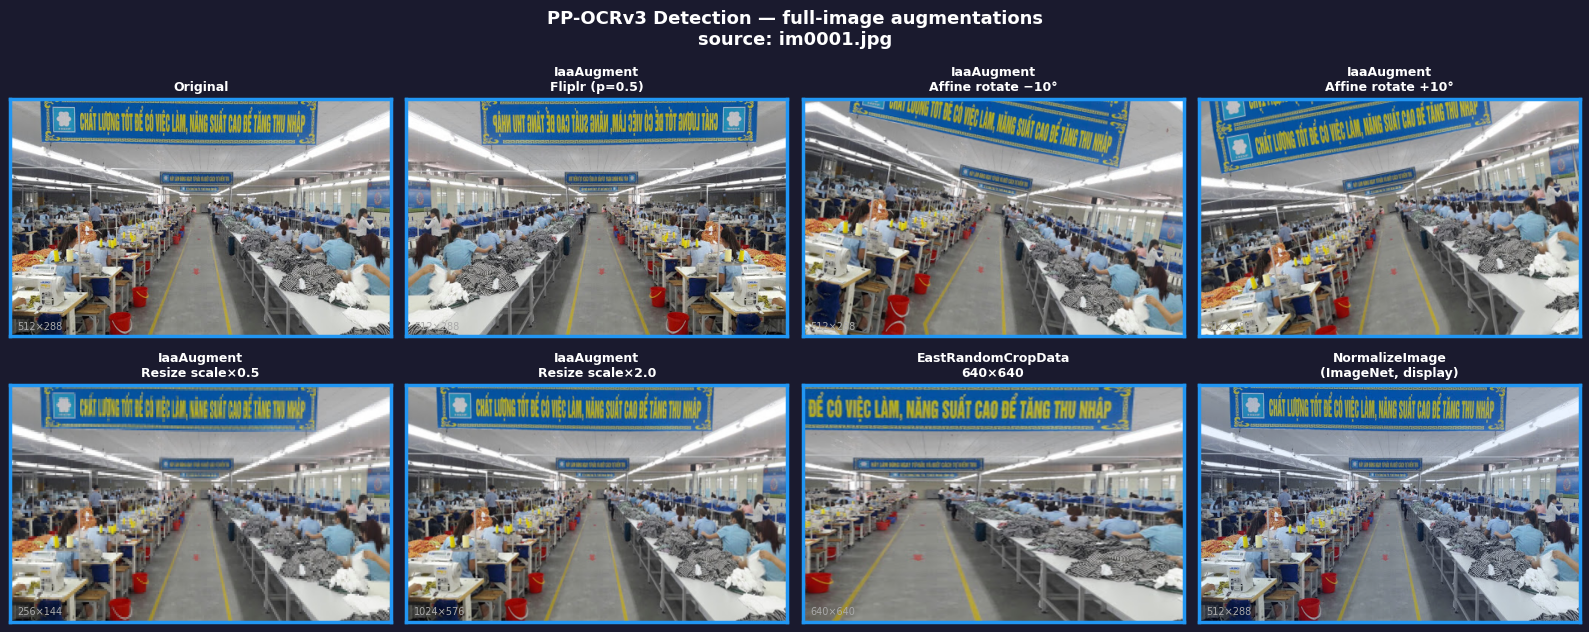

In [13]:
# ============================================================
# Plot 1 — Detection: full-image augmentations
# ============================================================
random.seed(SEED)

def bgr2rgb(x): return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

det_views = [
    ("Original",                             bgr2rgb(img_bgr)),
    ("IaaAugment\nFliplr (p=0.5)",           bgr2rgb(aug_fliplr(img_bgr))),
    ("IaaAugment\nAffine rotate −10°",       bgr2rgb(aug_rotate(img_bgr, -10))),
    ("IaaAugment\nAffine rotate +10°",       bgr2rgb(aug_rotate(img_bgr, +10))),
    ("IaaAugment\nResize scale×0.5",         bgr2rgb(aug_iaa_resize(img_bgr, 0.5))),
    ("IaaAugment\nResize scale×2.0",         bgr2rgb(aug_iaa_resize(img_bgr, 2.0))),
    ("EastRandomCropData\n640×640",          bgr2rgb(aug_east_random_crop(img_bgr, polys))),
    ("NormalizeImage\n(ImageNet, display)",  aug_normalize_display(img_bgr)),
]

COLS = 4; ROWS = (len(det_views)+COLS-1)//COLS
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS*4, ROWS*3.2), facecolor="#1a1a2e")
fig.suptitle(f"PP-OCRv3 Detection — full-image augmentations\nsource: {os.path.basename(sample_path)}",
             fontsize=13, fontweight="bold", color="white")
for i, (title, img) in enumerate(det_views):
    ax = axes.flatten()[i]
    ax.imshow(img, aspect="auto")
    ax.set_title(title, fontsize=9, color="white", fontweight="bold")
    ax.text(0.02, 0.02, f"{img.shape[1]}×{img.shape[0]}", transform=ax.transAxes,
            fontsize=7, color="#aaa", ha="left", va="bottom")
    for sp in ax.spines.values(): sp.set_edgecolor("#2196F3"); sp.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor("#0d0d1a")
for j in range(len(det_views), len(axes.flatten())): axes.flatten()[j].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/ppocrv3_det_augmentations.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

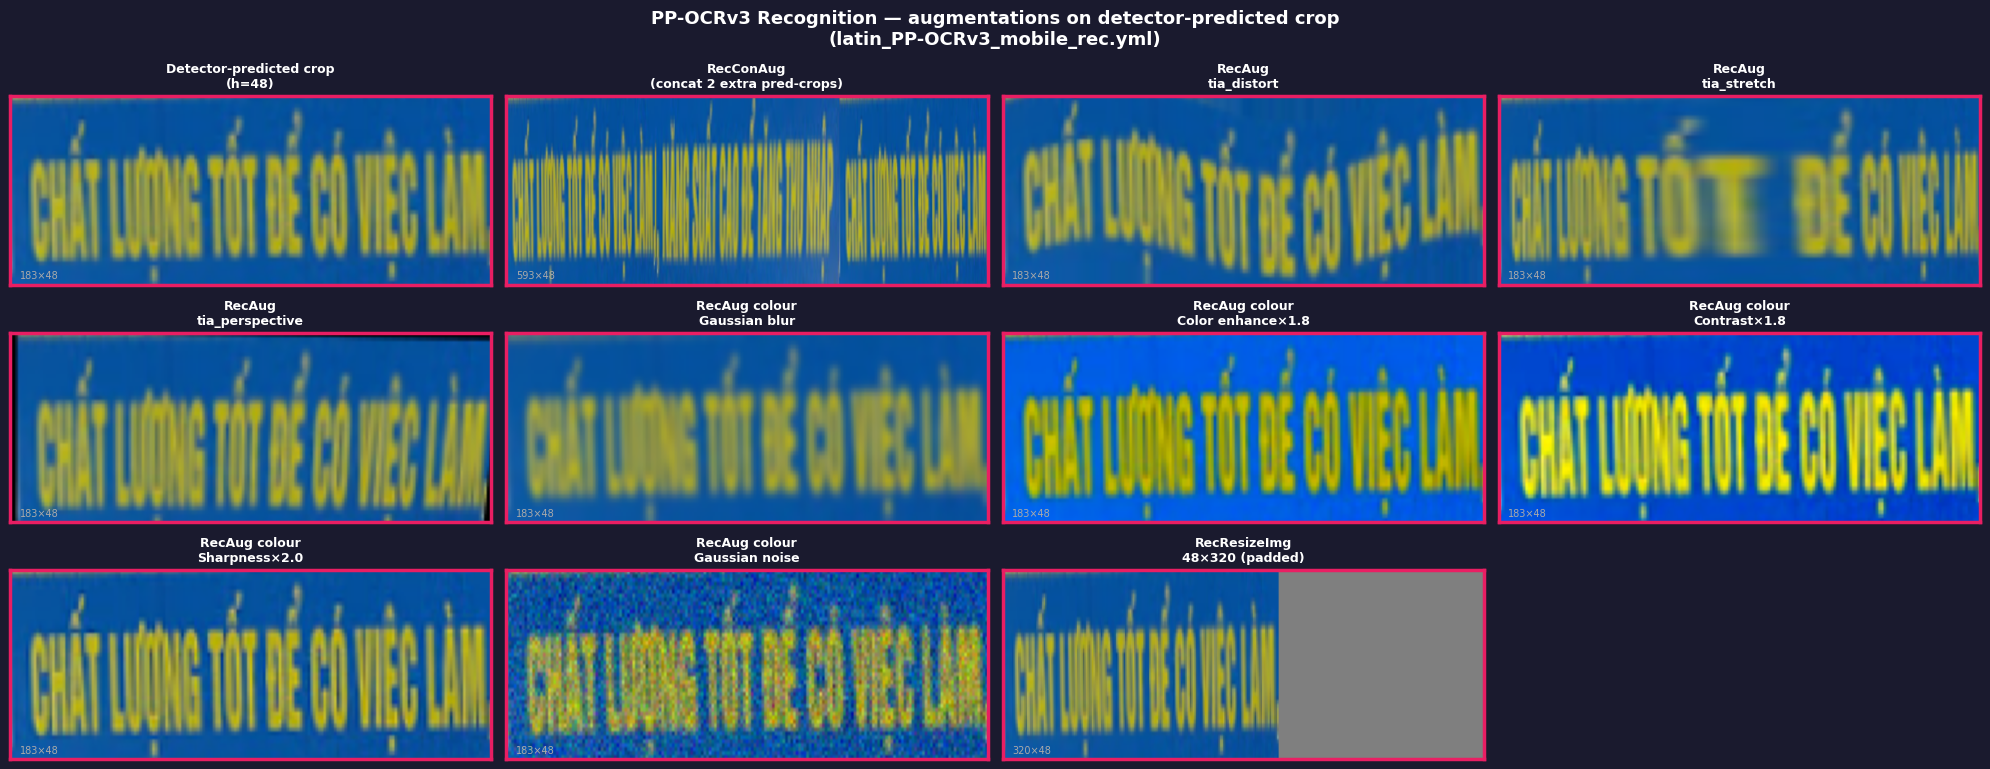

Saved → /kaggle/working/ppocrv3_det_augmentations.png
Saved → /kaggle/working/ppocrv3_rec_augmentations.png


In [14]:
# ============================================================
# Plot 2 — Recognition: augmentations on detector-predicted crop
# ============================================================
random.seed(SEED)

rec_views = [
    ("Detector-predicted crop\n(h=48)",         bgr2rgb(crop_bgr)),
    ("RecConAug\n(concat 2 extra pred-crops)",  bgr2rgb(aug_rec_con_aug(img_bgr, pred_quads, crop_bgr))),
    ("RecAug\ntia_distort",                     bgr2rgb(aug_tia_distort(crop_bgr))),
    ("RecAug\ntia_stretch",                     bgr2rgb(aug_tia_stretch(crop_bgr))),
    ("RecAug\ntia_perspective",                 bgr2rgb(aug_tia_perspective(crop_bgr))),
    ("RecAug colour\nGaussian blur",            bgr2rgb(aug_rec_blur(crop_bgr))),
    ("RecAug colour\nColor enhance×1.8",       bgr2rgb(aug_rec_color(crop_bgr))),
    ("RecAug colour\nContrast×1.8",            bgr2rgb(aug_rec_contrast(crop_bgr))),
    ("RecAug colour\nSharpness×2.0",           bgr2rgb(aug_rec_sharpness(crop_bgr))),
    ("RecAug colour\nGaussian noise",          bgr2rgb(aug_rec_noise(crop_bgr))),
    ("RecResizeImg\n48×320 (padded)",          bgr2rgb(aug_rec_resize(crop_bgr))),
]

COLS = 4; ROWS = (len(rec_views)+COLS-1)//COLS
fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS*5, ROWS*2.6), facecolor="#1a1a2e")
fig.suptitle("PP-OCRv3 Recognition — augmentations on detector-predicted crop\n"
             "(latin_PP-OCRv3_mobile_rec.yml)",
             fontsize=13, fontweight="bold", color="white")
for i, (title, img) in enumerate(rec_views):
    ax = axes.flatten()[i]
    ax.imshow(img, aspect="auto")
    ax.set_title(title, fontsize=9, color="white", fontweight="bold")
    ax.text(0.02, 0.02, f"{img.shape[1]}×{img.shape[0]}", transform=ax.transAxes,
            fontsize=7, color="#aaa", ha="left", va="bottom")
    for sp in ax.spines.values(): sp.set_edgecolor("#E91E63"); sp.set_linewidth(2.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor("#0d0d1a")
for j in range(len(rec_views), len(axes.flatten())): axes.flatten()[j].set_visible(False)
plt.tight_layout()
plt.savefig("/kaggle/working/ppocrv3_rec_augmentations.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("Saved → /kaggle/working/ppocrv3_det_augmentations.png")
print("Saved → /kaggle/working/ppocrv3_rec_augmentations.png")